In [142]:
!python -m pip install geopy
!python.exe -m pip install --upgrade pip

In [143]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from sklearn.neighbors import NearestNeighbors

In [144]:
df = pd.read_csv("weatherAUS_2026C1.csv")
df

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145407,145454,2017-06-20,Uluru,2.6,22.0,0.0,NaN,NaN,E,29.0,...,26.5,1024.8,1021.2,NaN,NaN,10.1,21.6,No,No,0.0
145408,145455,2017-06-21,Uluru,3.1,23.2,0.0,NaN,NaN,E,31.0,...,24.7,1024.3,1020.5,NaN,NaN,11.1,21.5,No,No,0.0
145409,145456,2017-06-22,Uluru,3.6,26.0,0.0,NaN,NaN,NNW,21.0,...,21.4,1023.3,1018.4,NaN,NaN,11.8,24.5,No,No,0.0
145410,145457,2017-06-23,Uluru,4.8,27.4,0.0,NaN,NaN,N,39.0,...,23.7,1021.0,1016.0,NaN,NaN,12.0,26.9,No,No,0.0


In [145]:
df = df.drop(columns="Unnamed: 0")

In [146]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'RainfallTomorrow'],
      dtype='str')

In [147]:
df.describe(include='all')

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
count,145412,145412,143928.000000,144159.000000,142152.000000,82658.000000,75616.000000,135096,135159.000000,134850,...,140907.000000,130351.000000,130388.000000,89542.000000,86076.000000,143646.000000,141805.000000,142152,142153,142153.000000
unique,3435,49,NaN,NaN,NaN,NaN,NaN,16,NaN,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN
top,2013-03-01,Canberra,NaN,NaN,NaN,NaN,NaN,W,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,NaN
freq,49,3435,NaN,NaN,NaN,NaN,NaN,9910,NaN,11754,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110276,110281,NaN
mean,NaN,NaN,12.196528,23.223064,2.361516,5.468616,7.611241,NaN,40.036668,NaN,...,51.532206,1017.647237,1015.255080,4.447287,4.509770,16.991981,21.683360,NaN,NaN,2.361242
std,NaN,NaN,6.417956,7.135927,8.479338,4.193871,3.785612,NaN,13.648259,NaN,...,20.844414,7.113833,7.044507,2.887161,2.720306,6.509191,6.953072,NaN,NaN,8.479084
min,NaN,NaN,-9.700000,-5.100000,0.000000,0.000000,0.000000,NaN,6.000000,NaN,...,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,NaN,NaN,0.000000
25%,NaN,NaN,7.600000,17.900000,0.000000,2.600000,4.800000,NaN,31.000000,NaN,...,36.600000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,NaN,NaN,0.000000
50%,NaN,NaN,12.000000,22.600000,0.000000,4.800000,8.400000,NaN,38.000000,NaN,...,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,NaN,NaN,0.000000
75%,NaN,NaN,16.900000,28.200000,0.800000,7.400000,10.600000,NaN,48.000000,NaN,...,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,NaN,NaN,0.800000


De las columnas presentes se puede entender que representan lo siguiente:  
unnamed = Esta columna debe ser el index original de la misma
Date = Fecha  
Location = Ubicación  
MinTemp = Temperatura Minima en ºC  
MaxTemp = Temperatura Máxima en ºC  
Rainfall = cantidad de lluvia en el periodo de 24hs en mm  
Evaporation = Evaporación de liquido en un recipiente abierto en un periodo de 24hs en mm  
Sunshine = cantidad de horas de sol en el día  
WindGustDir = Dirección de ráfagas de viento, expresada en dirección cardinal, se entiende que habla de ráfaga máxima   
WindGustSpeed = Velocidad del viento en esa ráfaga, expresada en km/h  
WindDir9am/3pm = Dirección del viento, expresada en dirección cardinal, en esos respectivos horarios  
WindSpeed9am/3pm = Velocidad del viento en esos respectivos horarios en km/h  
Humidity9am/3pm = Humedad en ese horario, en %  
Pressure9am/3pm = Presión atmosferica en ese horario, en hPa  
cloud9am/3pm = Variable Categorica que expresa tipo de Nube en ese momento  
Temp9am/3pm = Temperatura en ese horario, en ºC  
RainToday = si ha llovido hoy  
RainTomorrow = si va a llover mañana  
RainfallTomorrow =cuanta cantidad se espera de lluvia mañana?  

Se ha usado información del Australian National Bureau of Meteorology para poder entender correctamente el significado de cada variable

In [148]:
df.isnull().sum()

Date                    0
Location                0
MinTemp              1484
MaxTemp              1253
Rainfall             3260
Evaporation         62754
Sunshine            69796
WindGustDir         10316
WindGustSpeed       10253
WindDir9am          10562
WindDir3pm           4226
WindSpeed9am         1767
WindSpeed3pm         3061
Humidity9am          2653
Humidity3pm          4505
Pressure9am         15061
Pressure3pm         15024
Cloud9am            55870
Cloud3pm            59336
Temp9am              1766
Temp3pm              3607
RainToday            3260
RainTomorrow         3259
RainfallTomorrow     3259
dtype: int64

teniendo columnas con hasta 69k de datos faltantes se descarta la opción de eliminar las entradas que presenten nulos ya que se considera que esto afectaría a la calidad del trabajo.

In [149]:
df.nunique()

Date                3435
Location              49
MinTemp              395
MaxTemp              506
Rainfall             681
Evaporation          358
Sunshine             145
WindGustDir           16
WindGustSpeed        120
WindDir9am            16
WindDir3pm            16
WindSpeed9am          76
WindSpeed3pm          75
Humidity9am          983
Humidity3pm          995
Pressure9am          547
Pressure3pm          542
Cloud9am              10
Cloud3pm              10
Temp9am              446
Temp3pm              503
RainToday              2
RainTomorrow           2
RainfallTomorrow     681
dtype: int64

In [150]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              145412 non-null  str    
 1   Location          145412 non-null  str    
 2   MinTemp           143928 non-null  float64
 3   MaxTemp           144159 non-null  float64
 4   Rainfall          142152 non-null  float64
 5   Evaporation       82658 non-null   float64
 6   Sunshine          75616 non-null   float64
 7   WindGustDir       135096 non-null  str    
 8   WindGustSpeed     135159 non-null  float64
 9   WindDir9am        134850 non-null  str    
 10  WindDir3pm        141186 non-null  str    
 11  WindSpeed9am      143645 non-null  float64
 12  WindSpeed3pm      142351 non-null  float64
 13  Humidity9am       142759 non-null  float64
 14  Humidity3pm       140907 non-null  float64
 15  Pressure9am       130351 non-null  float64
 16  Pressure3pm       130388 non-nu

In [151]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df = df.drop(columns=["Date"])


# Tipo de variables en el dataset:
|Tipo|Variables|
|----|-----|
|Numéricas|MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustSpeed WindSpeed9am. WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Temp9am, Temp3pm|
|Categóricas|Location, WindGustDir, WindDir9am, WindDirs3pm, Cloud9am, Cloud3pm, RainToday, RainfallTomorrow|
|Temporales|Year, Month, Day|
|Target|RainTomorrow|


In [152]:
df["RainTomorrow"].value_counts(normalize=True)

RainTomorrow
No     0.775791
Yes    0.224209
Name: proportion, dtype: float64

<Axes: xlabel='RainTomorrow', ylabel='count'>

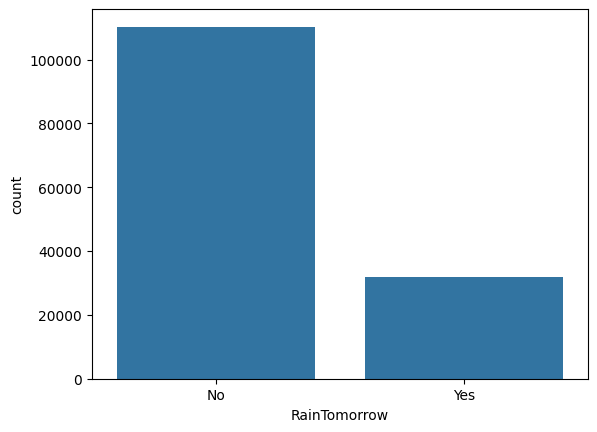

In [153]:
sns.countplot(x="RainTomorrow", data=df)

Existe desbalanceo moderado entre clases, lo cual deberá considerarse posteriormente durante el modelado.

In [154]:
df.drop_duplicates(inplace=True)

In [155]:
def faltantes(data: pd.DataFrame) -> pd.DataFrame:
    faltantes = data.isnull().sum()
    porcentaje = (faltantes / len(df)) * 100

    return porcentaje
faltantes(df)

Location             0.000000
MinTemp              1.020549
MaxTemp              0.861690
Rainfall             2.241906
Evaporation         43.155998
Sunshine            47.998790
WindGustDir          7.094325
WindGustSpeed        7.051000
WindDir9am           7.263500
WindDir3pm           2.906225
WindSpeed9am         1.215168
WindSpeed3pm         2.105053
Humidity9am          1.824471
Humidity3pm          3.098094
Pressure9am         10.357467
Pressure3pm         10.332022
Cloud9am            38.421863
Cloud3pm            40.805436
Temp9am              1.214480
Temp3pm              2.480538
RainToday            2.241906
RainTomorrow         2.241218
RainfallTomorrow     2.241218
Year                 0.000000
Month                0.000000
Day                  0.000000
dtype: float64

se observa una perdida de casi la mitad de los datos en las variables Cloud, Sunshine y Evaporación. Se procede a borrar el 2% de entries de RainTomorrow, ya que inputarlos introduciría error al modelo.

In [156]:
df = df.dropna(subset=["RainTomorrow"])
faltantes(df)

Location             0.000000
MinTemp              0.448109
MaxTemp              0.226516
Rainfall             0.989075
Evaporation         42.779259
Sunshine            47.684537
WindGustDir          6.561944
WindGustSpeed        6.519736
WindDir9am           7.041005
WindDir3pm           2.656293
WindSpeed9am         0.948274
WindSpeed3pm         1.849416
Humidity9am          1.247951
Humidity3pm          2.538814
Pressure9am          9.855578
Pressure3pm          9.832364
Cloud9am            37.734694
Cloud3pm            40.151105
Temp9am              0.635935
Temp3pm              1.916949
RainToday            0.989075
RainTomorrow         0.000000
RainfallTomorrow     0.000000
Year                 0.000000
Month                0.000000
Day                  0.000000
dtype: float64

No resulta válido imputar la variable objetivo debido a que introduciría información artificial en el aprendizaje supervisado.

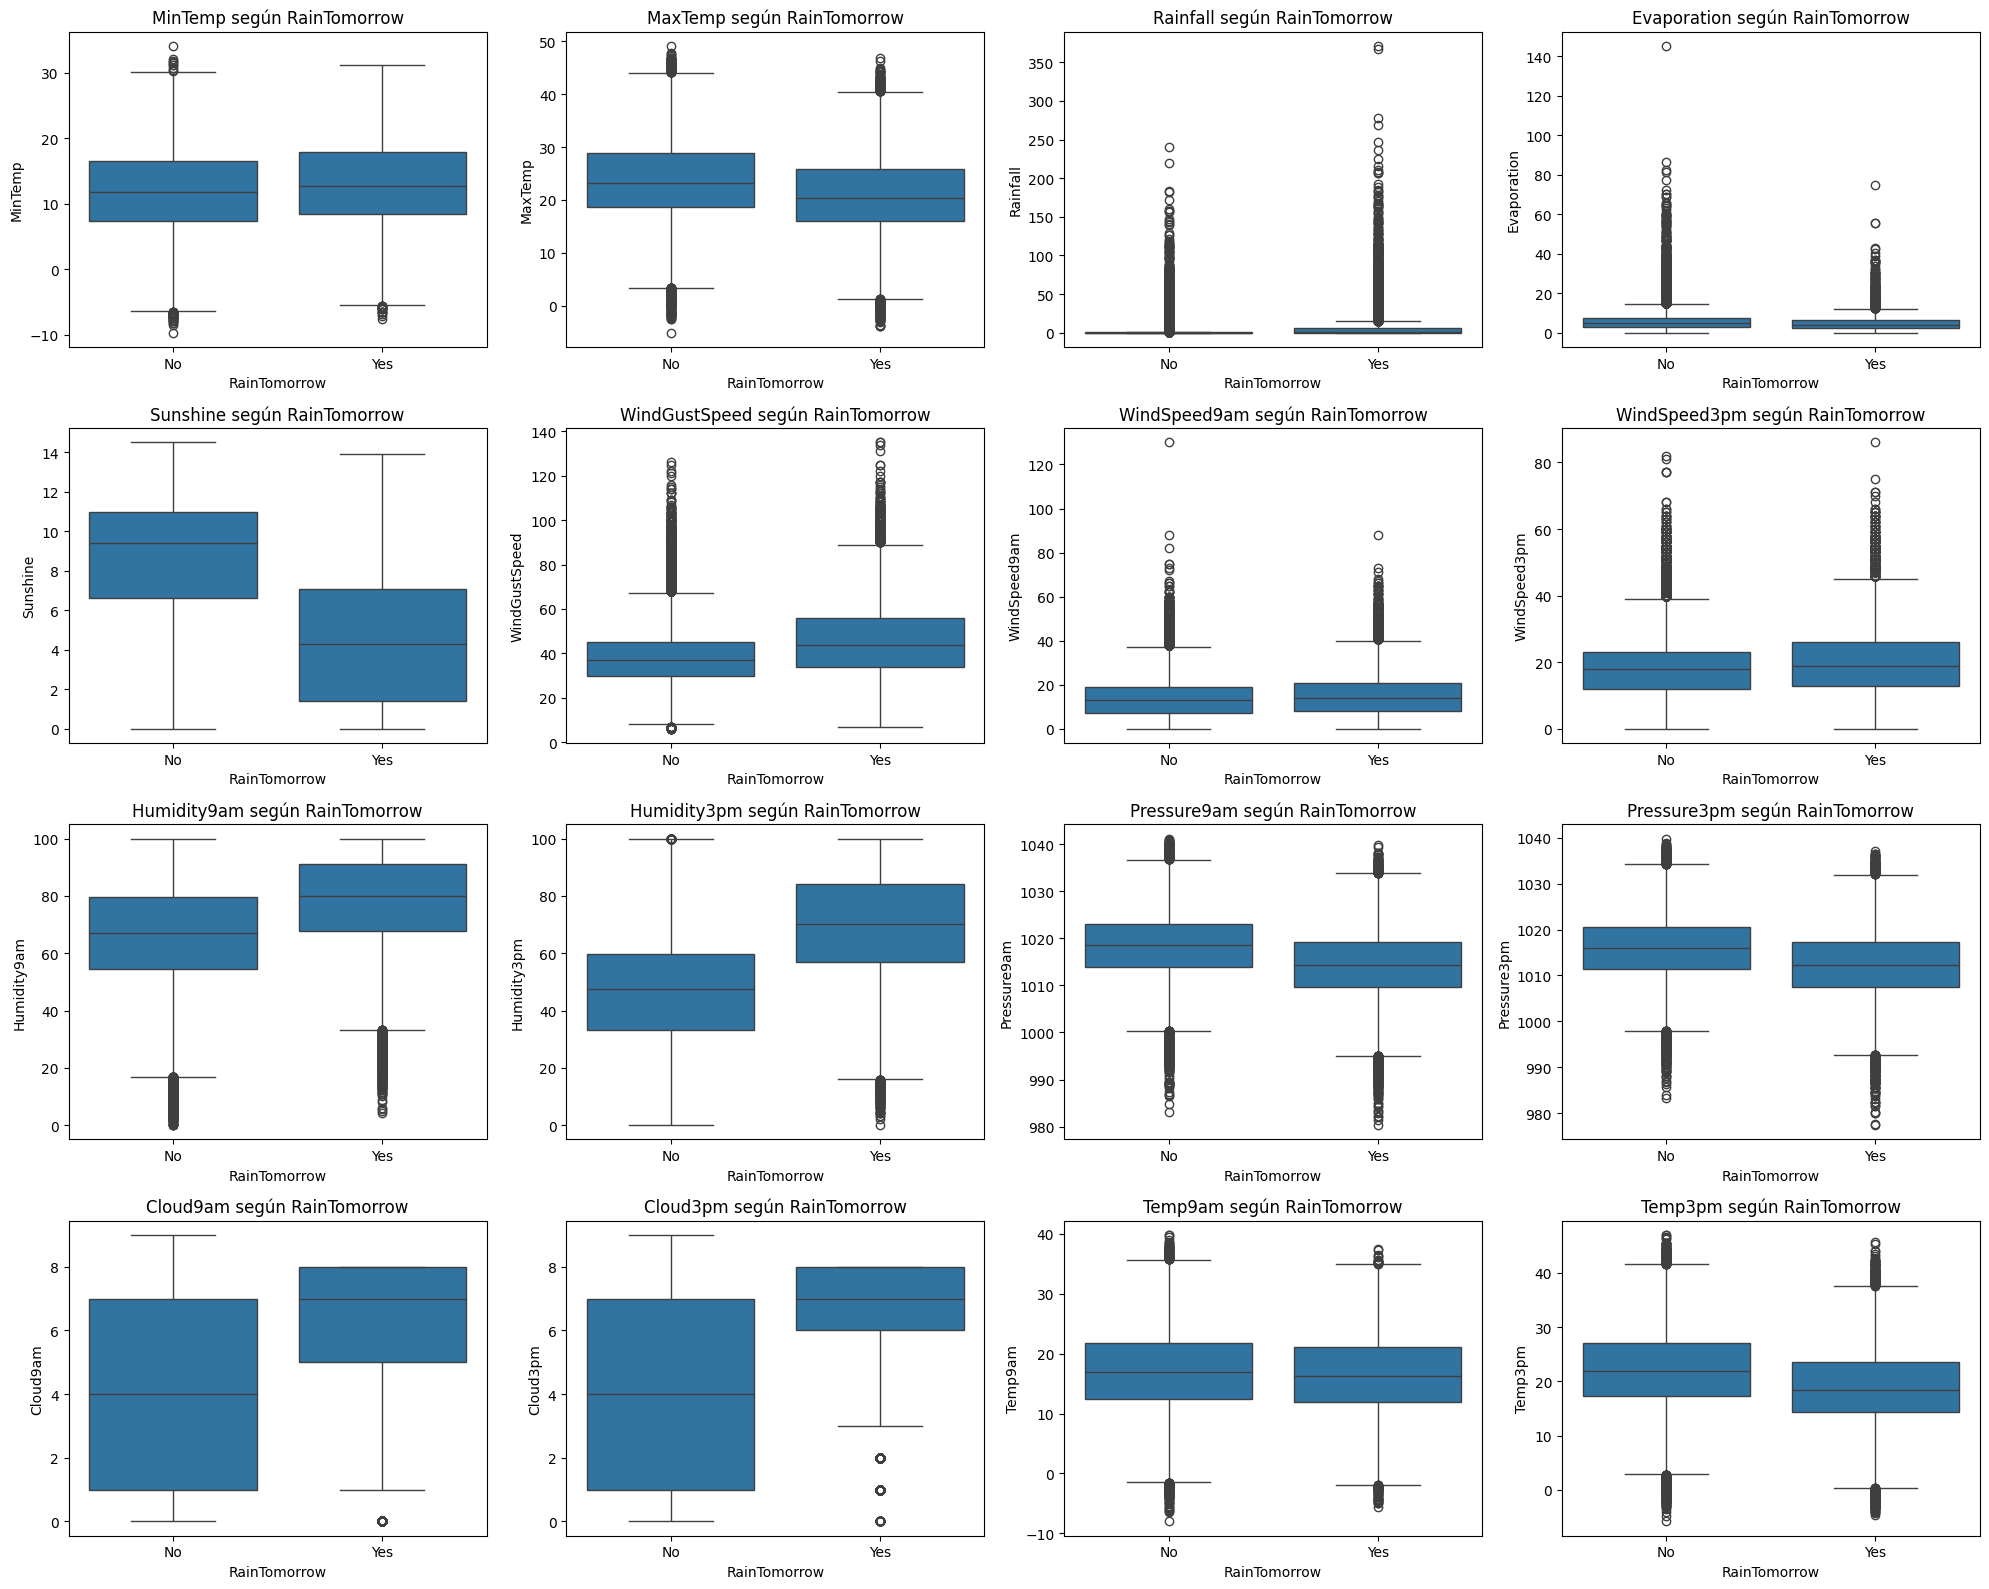

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Variables numéricas a comparar contra RainTomorrow
num_cols = [
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "Evaporation",
    "Sunshine",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Humidity9am",
    "Humidity3pm",
    "Pressure9am",
    "Pressure3pm",
    "Cloud9am",
    "Cloud3pm",
    "Temp9am",
    "Temp3pm"
]

# Nos aseguramos de que existan en el dataframe
num_cols = [col for col in num_cols if col in df.columns]

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(
        data=df,
        x="RainTomorrow",
        y=col
    )
    plt.title(f"{col} según RainTomorrow")
    plt.xlabel("RainTomorrow")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [158]:
df.columns

Index(['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'RainfallTomorrow', 'Year',
       'Month', 'Day'],
      dtype='str')

In [159]:
cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
        'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
        'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am',
        'Temp3pm']

def resumen_distribuciones(df):

    resumen = {}

    for col in cols:

        serie = df[col].dropna()

        Q1 = serie.quantile(0.25)
        Q3 = serie.quantile(0.75)

        resumen[col] = {
            "mean": serie.mean(),
            "median": serie.median(),
            "std": serie.std(),
            "var": serie.var(),
            "min": serie.min(),
            "max": serie.max(),
            "IQR": Q3 - Q1,
            "skew": serie.skew(),
            "kurtosis": serie.kurtosis(),
            "missing_pct": df[col].isnull().mean() * 100
        }

    resumen_df = pd.DataFrame(resumen).T

    return resumen_df   

In [160]:
distribuciones_previo = resumen_distribuciones(df)
distribuciones_previo


,mean,median,std,var,min,max,IQR,skew,kurtosis,missing_pct
MinTemp,12.188866,12.0,6.422856,41.253084,-9.7,34.1,9.2,0.022221,-0.481609,0.448109
MaxTemp,23.228596,22.6,7.134436,50.900172,-5.1,49.1,10.3,0.222679,-0.235140,0.226516
Rainfall,2.350461,0.0,8.466267,71.677678,0.0,371.0,0.8,9.886866,179.957216,0.989075
Evaporation,5.470149,4.8,4.188649,17.544780,0.0,145.0,4.8,3.746758,45.066745,42.779259
Sunshine,7.624919,8.5,3.781656,14.300920,0.0,14.5,5.7,-0.502936,-0.820411,47.684537
WindGustSpeed,39.985807,38.0,13.630314,185.785461,6.0,135.0,17.0,0.866666,1.401362,6.519736
WindSpeed9am,14.025219,13.0,8.914326,79.465210,0.0,130.0,12.0,0.785296,1.220041,0.948274
WindSpeed3pm,18.636901,18.0,8.858849,78.479205,0.0,86.0,12.0,0.619921,0.741008,1.849416
Humidity9am,68.824619,69.9,19.085026,364.238205,0.0,100.0,26.2,-0.484886,-0.044226,1.247951
Humidity3pm,51.475886,51.9,20.846540,434.578228,0.0,100.0,29.1,0.032263,-0.509691,2.538814


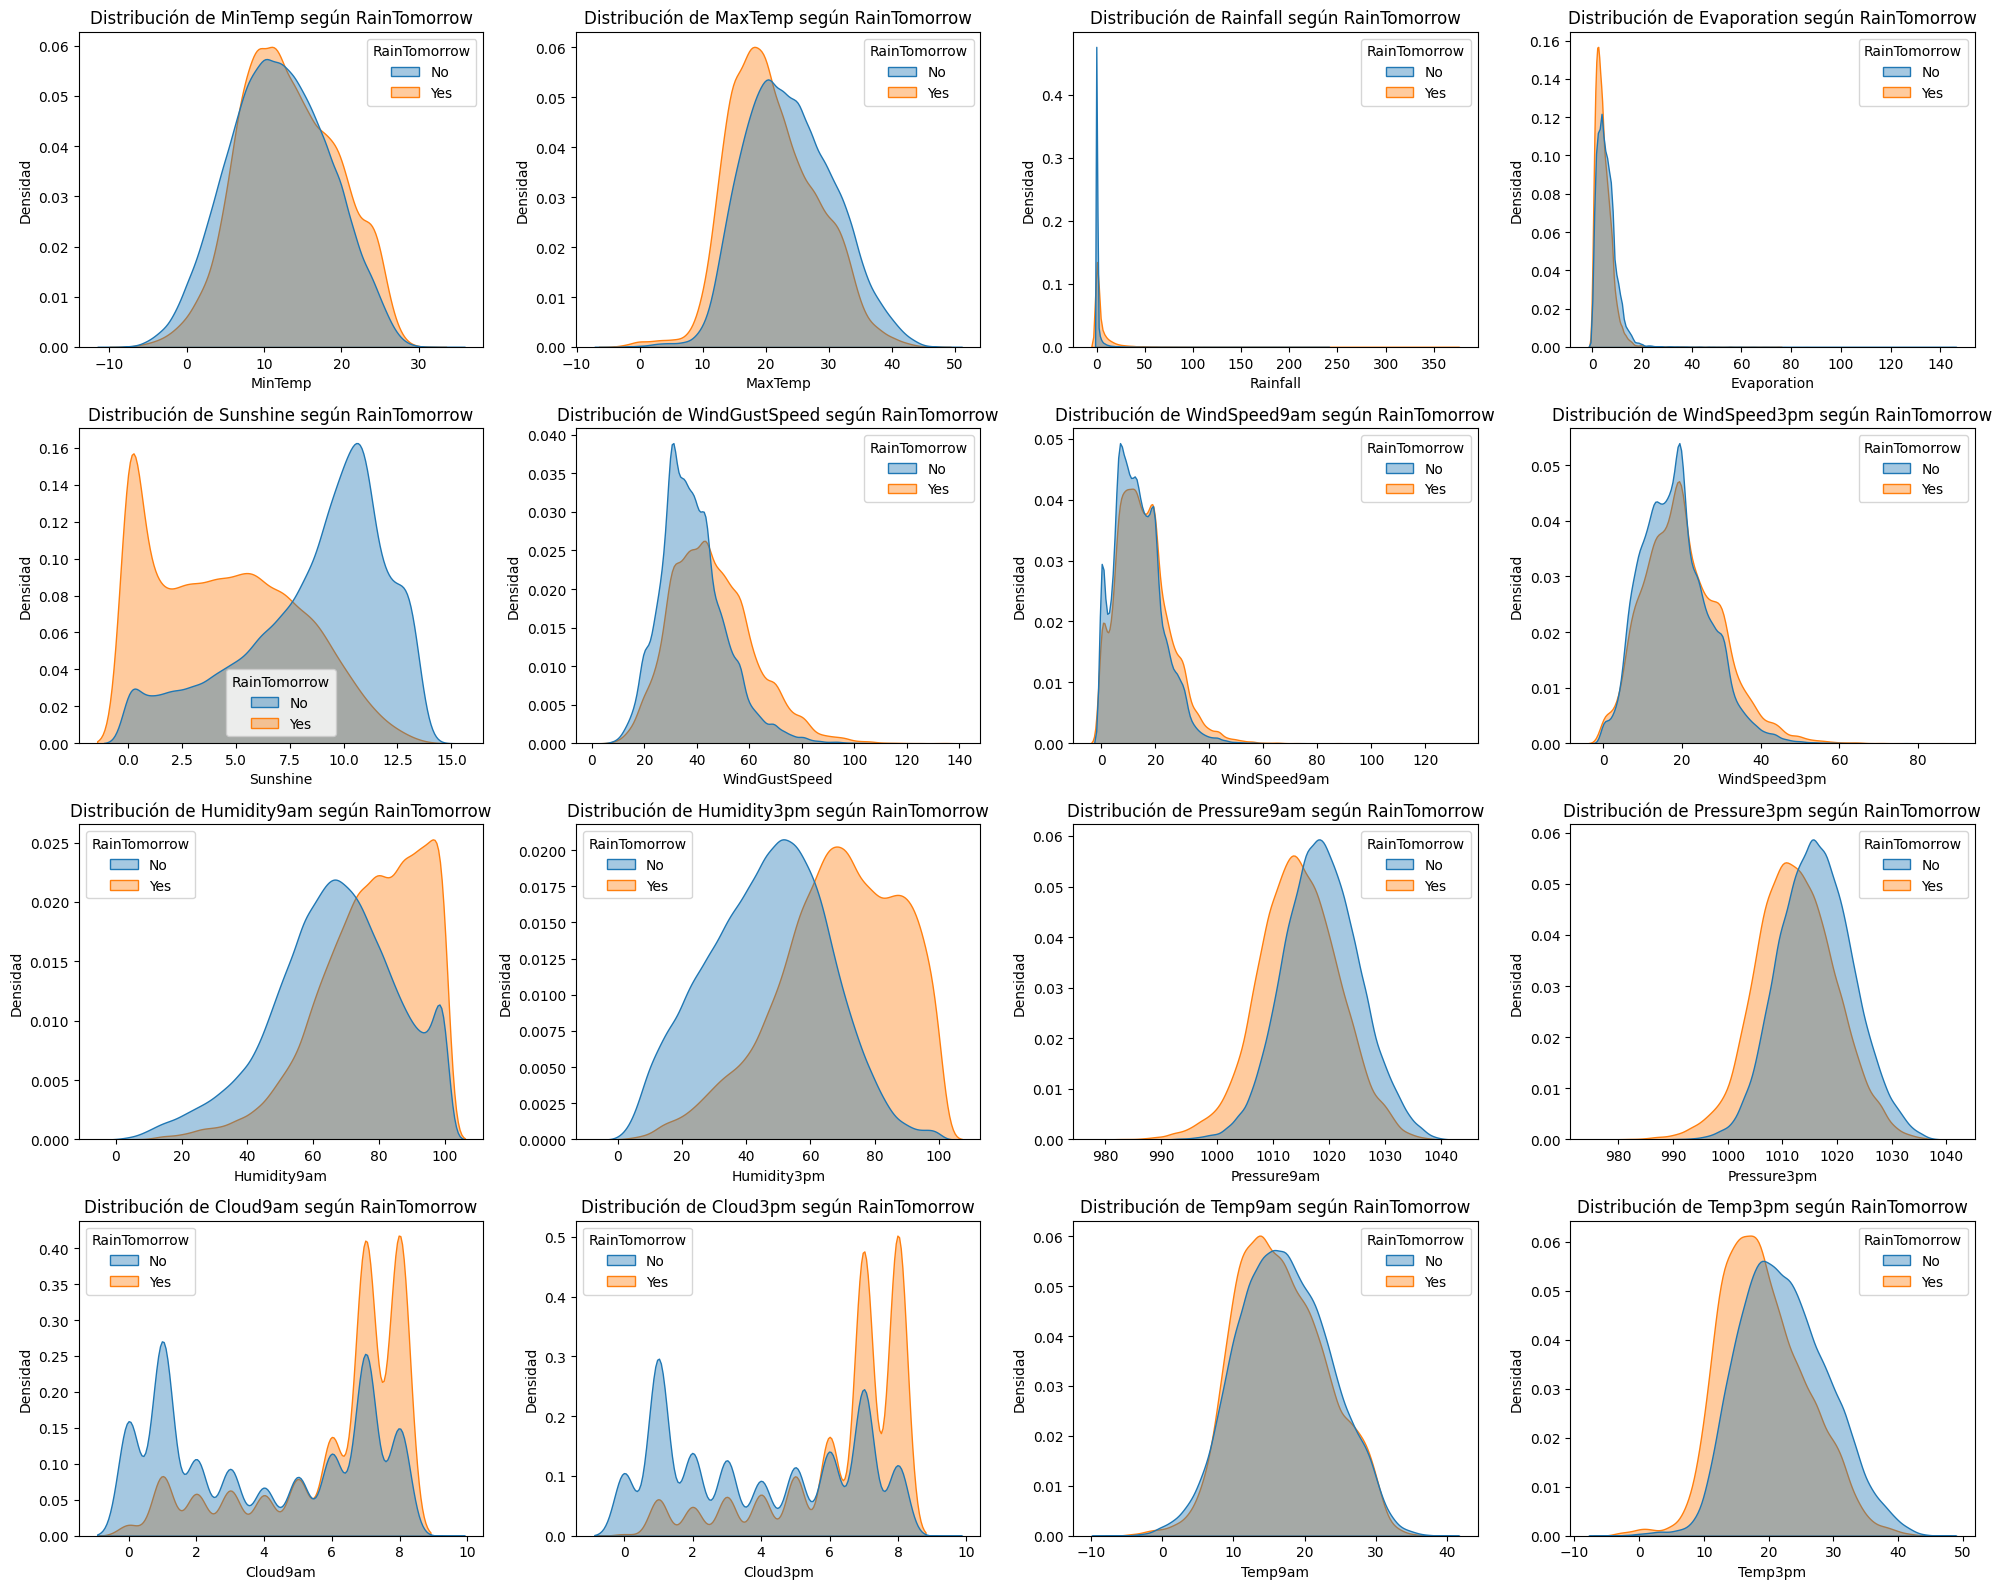

In [161]:
plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.kdeplot(
        data=df,
        x=col,
        hue="RainTomorrow",
        fill=True,
        common_norm=False,
        alpha=0.4
    )
    plt.title(f"Distribución de {col} según RainTomorrow")
    plt.xlabel(col)
    plt.ylabel("Densidad")

plt.tight_layout()
plt.show()

A simple vista se ve mucha señal predictiva en variaibles cómo: MaxTemp, Sunshine, WindGustSpeed, Humidity, Pressure, Cloud y Temp3pm. Se nota que Sunshine y Cloud9am y 3pm (que tienen un ~40% de valores faltantes) tienen una fuerte relación con el target, mientras que a simple vista, Evaporation (que posee un 43% de faltantes) no.

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns

#Armamos una función que analice los nan de una columna

def Analizar_Var(df: pd.DataFrame ,col: str):

    print(f"ANÁLISIS DE NaN -> {col}")

    nan_pct = df[col].isnull().mean() * 100

    print(f"\n% faltantes total: {nan_pct:.2f}%")

    #Cálculo de los faltantes por ubicación y mes

    nan_flag = f"{col}_nan"

    df[nan_flag] = df[col].isnull()

    print("\n% NaN por Lugar:")

    display(
        (
            df.groupby("Location")[col]
            .apply(lambda x: x.isnull().mean() * 100)
            .sort_values(ascending=False)
            .to_frame("% NaN")
        )
    )


    print("\n% NaN por mes:")

    display(
        (
            df.groupby("Month")[col]
            .apply(lambda x: x.isnull().mean() * 100)
            .sort_values(ascending=False)
            .to_frame("% NaN")
        )
    )


    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x="RainTomorrow",
        hue=nan_flag
    )

    plt.title(f"NaN de {col} según RainTomorrow")

    plt.show()

ANÁLISIS DE NaN -> Evaporation

% faltantes total: 42.78%

% NaN por Lugar:


,% NaN
Location,
Albury,100.000000
Ballarat,100.000000
BadgerysCreek,100.000000
GoldCoast,100.000000
PearceRAAF,100.000000
Witchcliffe,100.000000
Wollongong,100.000000
Walpole,100.000000
Uluru,100.000000



% NaN por mes:


,% NaN
Month,
6,44.311280
5,44.113367
4,43.499027
1,43.402213
12,43.395005
2,43.087886
3,42.712488
10,42.316164
11,42.273798


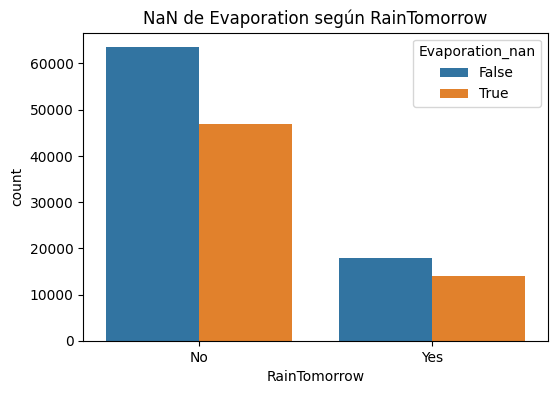

In [163]:
Analizar_Var(df,"Evaporation")

ANÁLISIS DE NaN -> Cloud9am

% faltantes total: 37.73%

% NaN por Lugar:


,% NaN
Location,
Adelaide,100.000000
BadgerysCreek,100.000000
Dartmoor,100.000000
GoldCoast,100.000000
Walpole,100.000000
Nhil,100.000000
NorahHead,100.000000
Penrith,100.000000
MountGinini,100.000000



% NaN por mes:


,% NaN
Month,
12,39.232192
1,39.029487
10,38.622501
5,38.284182
4,38.209800
3,38.071494
11,38.024605
2,38.014252
9,37.091230


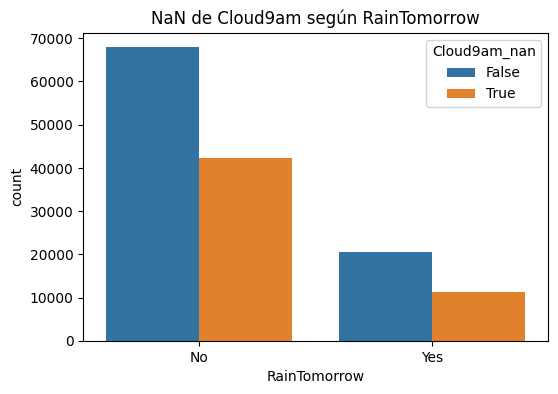

In [164]:
Analizar_Var(df,"Cloud9am")

ANÁLISIS DE NaN -> Cloud3pm

% faltantes total: 40.15%

% NaN por Lugar:


,% NaN
Location,
Adelaide,100.000000
BadgerysCreek,100.000000
Dartmoor,100.000000
GoldCoast,100.000000
Walpole,100.000000
Nhil,100.000000
NorahHead,100.000000
Penrith,100.000000
MountGinini,100.000000



% NaN por mes:


,% NaN
Month,
1,42.179398
12,42.118409
2,41.292162
11,41.270395
10,41.070823
5,40.773650
3,40.349801
4,40.084911
6,39.233946


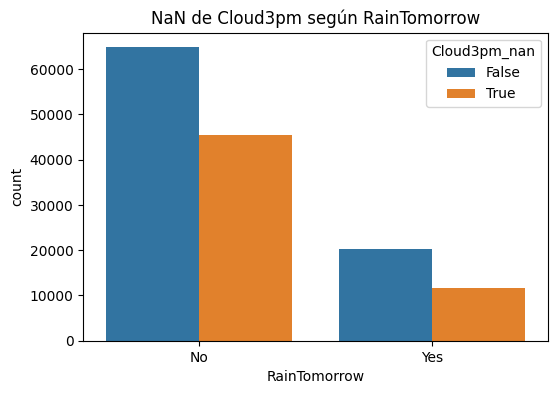

In [165]:
Analizar_Var(df,"Cloud3pm")

ANÁLISIS DE NaN -> Sunshine

% faltantes total: 47.68%

% NaN por Lugar:


,% NaN
Location,
Albury,100.000000
GoldCoast,100.000000
BadgerysCreek,100.000000
Bendigo,100.000000
Ballarat,100.000000
Katherine,100.000000
Wollongong,100.000000
Walpole,100.000000
Uluru,100.000000



% NaN por mes:


,% NaN
Month,
5,50.072769
6,49.283343
12,48.390379
4,48.337166
8,47.287876
10,47.280583
1,47.117096
11,47.011605
2,47.002375


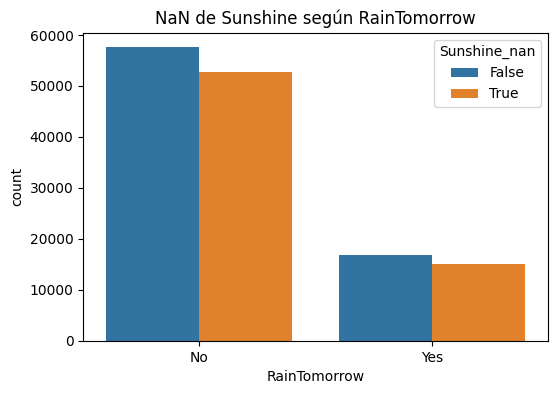

In [166]:
Analizar_Var(df,"Sunshine")

Se nota que hay ciudades que no tienen datos de algunas de las variables con muchos NaN, asumimos que es porque no tienen los sensores para hacerlo. Se procede a imputar los NaN usando de referencia los datos del mismo lugar en el mismo mes para los casos dónde los NaN son esporadicos, y en los casos dónde el dato no fué tomado será imputado promediando el valor del dato en los observatorios vecinos.

In [167]:
import re
geolocator = Nominatim(user_agent="weatherAUS_imputation")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

coords = []

lugares = df["Location"].unique().tolist()

for loc in lugares:

    query = query.replace("Airport", " Airport")
    query = re.sub(r'(?<!^)(?=[A-Z])', ' ', loc)
    query = query.replace(" R A A F", " RAAF")
    

    place = geocode(f"{query}, Australia")

    coords.append({
        "Location": loc,
        "Latitude": place.latitude if place else np.nan,
        "Longitude": place.longitude if place else np.nan
    })

lugares_coords = pd.DataFrame(coords)

lugares_coords

RateLimiter caught an error, retrying (0/2 tries). Called with (*('Richmond, Australia',), **{}).
Traceback (most recent call last):
  File "c:\Users\sebas\AppData\Local\Programs\Python\Python312\Lib\site-packages\geopy\adapters.py", line 298, in get_text
    page = self.urlopen(req, timeout=timeout)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\sebas\AppData\Local\Programs\Python\Python312\Lib\urllib\request.py", line 515, in open
    response = self._open(req, data)
               ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\sebas\AppData\Local\Programs\Python\Python312\Lib\urllib\request.py", line 532, in _open
    result = self._call_chain(self.handle_open, protocol, protocol +
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\sebas\AppData\Local\Programs\Python\Python312\Lib\urllib\request.py", line 492, in _call_chain
    result = func(*args)
             ^^^^^^^^^^^
  File "c:\Users\sebas\AppData\Local\Programs\Python\Python312\Lib\

,Location,Latitude,Longitude
0,Albury,-36.073773,146.913526
1,BadgerysCreek,-33.883145,150.742466
2,Cobar,-31.966663,145.304505
3,CoffsHarbour,-30.298600,153.109412
4,Moree,-29.461720,149.840715
5,Newcastle,-32.919295,151.779535
6,NorahHead,-33.281667,151.567778
7,NorfolkIsland,-29.032804,167.948314
8,Penrith,-33.751195,150.694171
9,Richmond,-37.807450,144.990721


In [168]:
coords_rad = np.radians(
    lugares_coords[["Latitude", "Longitude"]]
)

nn = NearestNeighbors(
    n_neighbors=6,
    metric="haversine"
)

nn.fit(coords_rad)

distances, indices = nn.kneighbors(coords_rad)

vecinos_dict = {}

for i, loc in enumerate(lugares_coords["Location"]):
    vecinos = lugares_coords.iloc[indices[i]]["Location"].tolist()
    vecinos = [v for v in vecinos if v != loc]
    vecinos_dict[loc] = vecinos

vecinos_dict

{'Albury': ['WaggaWagga', 'MountGinini', 'Tuggeranong', 'Canberra', 'Sale'],
 'BadgerysCreek': ['Penrith',
  'SydneyAirport',
  'Sydney',
  'Wollongong',
  'NorahHead'],
 'Cobar': ['Mildura', 'WaggaWagga', 'Albury', 'MountGinini', 'Canberra'],
 'CoffsHarbour': ['GoldCoast',
  'Williamtown',
  'Brisbane',
  'Newcastle',
  'Moree'],
 'Moree': ['CoffsHarbour',
  'Brisbane',
  'GoldCoast',
  'Williamtown',
  'Newcastle'],
 'Newcastle': ['Williamtown',
  'NorahHead',
  'Sydney',
  'SydneyAirport',
  'Penrith'],
 'NorahHead': ['Newcastle',
  'Williamtown',
  'Sydney',
  'SydneyAirport',
  'Penrith'],
 'NorfolkIsland': ['GoldCoast',
  'CoffsHarbour',
  'Brisbane',
  'Williamtown',
  'Newcastle'],
 'Penrith': ['BadgerysCreek',
  'Sydney',
  'SydneyAirport',
  'Wollongong',
  'NorahHead'],
 'Richmond': ['Melbourne',
  'Watsonia',
  'MelbourneAirport',
  'Ballarat',
  'Bendigo'],
 'Sydney': ['SydneyAirport',
  'BadgerysCreek',
  'Penrith',
  'Wollongong',
  'NorahHead'],
 'SydneyAirport': ['Sydn

In [169]:
def imputar_por_vecinos_geograficos(df, col, neighbors_dict):
    df = df.copy()

    # 1) Location + Month
    df[col] = df[col].fillna(
        df.groupby(["Location", "Month"])[col].transform("median")
    )

    # 2) Vecinos + Month
    for loc, vecinos in neighbors_dict.items():

        for month in df.loc[
            (df["Location"] == loc) & (df[col].isnull()),
            "Month"
        ].unique():

            mask = (
                (df["Location"] == loc) &
                (df["Month"] == month) &
                (df[col].isnull())
            )

            valores_vecinos = df[
                (df["Location"].isin(vecinos)) &
                (df["Month"] == month)
            ][col].dropna()

            if len(valores_vecinos) > 0:
                df.loc[mask, col] = valores_vecinos.median()

    return df

In [ ]:
cols_vecinos = [
    "Evaporation",
    "Sunshine",
    "Cloud9am",
    "Cloud3pm",
    "Pressure9am",
    "Pressure3pm"
]

for col in cols_vecinos:
    df = imputar_por_vecinos_geograficos(
        df,
        col,
        vecinos_dict
    )

faltantes(df)

Location            0.000000
MinTemp             0.448109
MaxTemp             0.226516
Rainfall            0.989075
Evaporation         0.000000
Sunshine            0.000000
WindGustDir         6.561944
WindGustSpeed       6.519736
WindDir9am          7.041005
WindDir3pm          2.656293
WindSpeed9am        0.948274
WindSpeed3pm        1.849416
Humidity9am         1.247951
Humidity3pm         2.538814
Pressure9am         0.000000
Pressure3pm         0.000000
Cloud9am            0.000000
Cloud3pm            0.000000
Temp9am             0.635935
Temp3pm             1.916949
RainToday           0.989075
RainTomorrow        0.000000
RainfallTomorrow    0.000000
Year                0.000000
Month               0.000000
Day                 0.000000
Evaporation_nan     0.000000
Cloud9am_nan        0.000000
Cloud3pm_nan        0.000000
Sunshine_nan        0.000000
dtype: float64

In [171]:
distribuciones_post = resumen_distribuciones(df)
distribuciones_post

,mean,median,std,var,min,max,IQR,skew,kurtosis,missing_pct
MinTemp,12.188866,12.0,6.422856,41.253084,-9.7,34.1,9.2,0.022221,-0.481609,0.448109
MaxTemp,23.228596,22.6,7.134436,50.900172,-5.1,49.1,10.3,0.222679,-0.235140,0.226516
Rainfall,2.350461,0.0,8.466267,71.677678,0.0,371.0,0.8,9.886866,179.957216,0.989075
Evaporation,5.161116,4.6,3.540328,12.533922,0.0,145.0,4.4,3.750076,52.388743,0.000000
Sunshine,7.956474,8.4,3.065199,9.395448,0.0,14.5,3.9,-0.703797,0.126794,0.000000
WindGustSpeed,39.985807,38.0,13.630314,185.785461,6.0,135.0,17.0,0.866666,1.401362,6.519736
WindSpeed9am,14.025219,13.0,8.914326,79.465210,0.0,130.0,12.0,0.785296,1.220041,0.948274
WindSpeed3pm,18.636901,18.0,8.858849,78.479205,0.0,86.0,12.0,0.619921,0.741008,1.849416
Humidity9am,68.824619,69.9,19.085026,364.238205,0.0,100.0,26.2,-0.484886,-0.044226,1.247951
Humidity3pm,51.475886,51.9,20.846540,434.578228,0.0,100.0,29.1,0.032263,-0.509691,2.538814


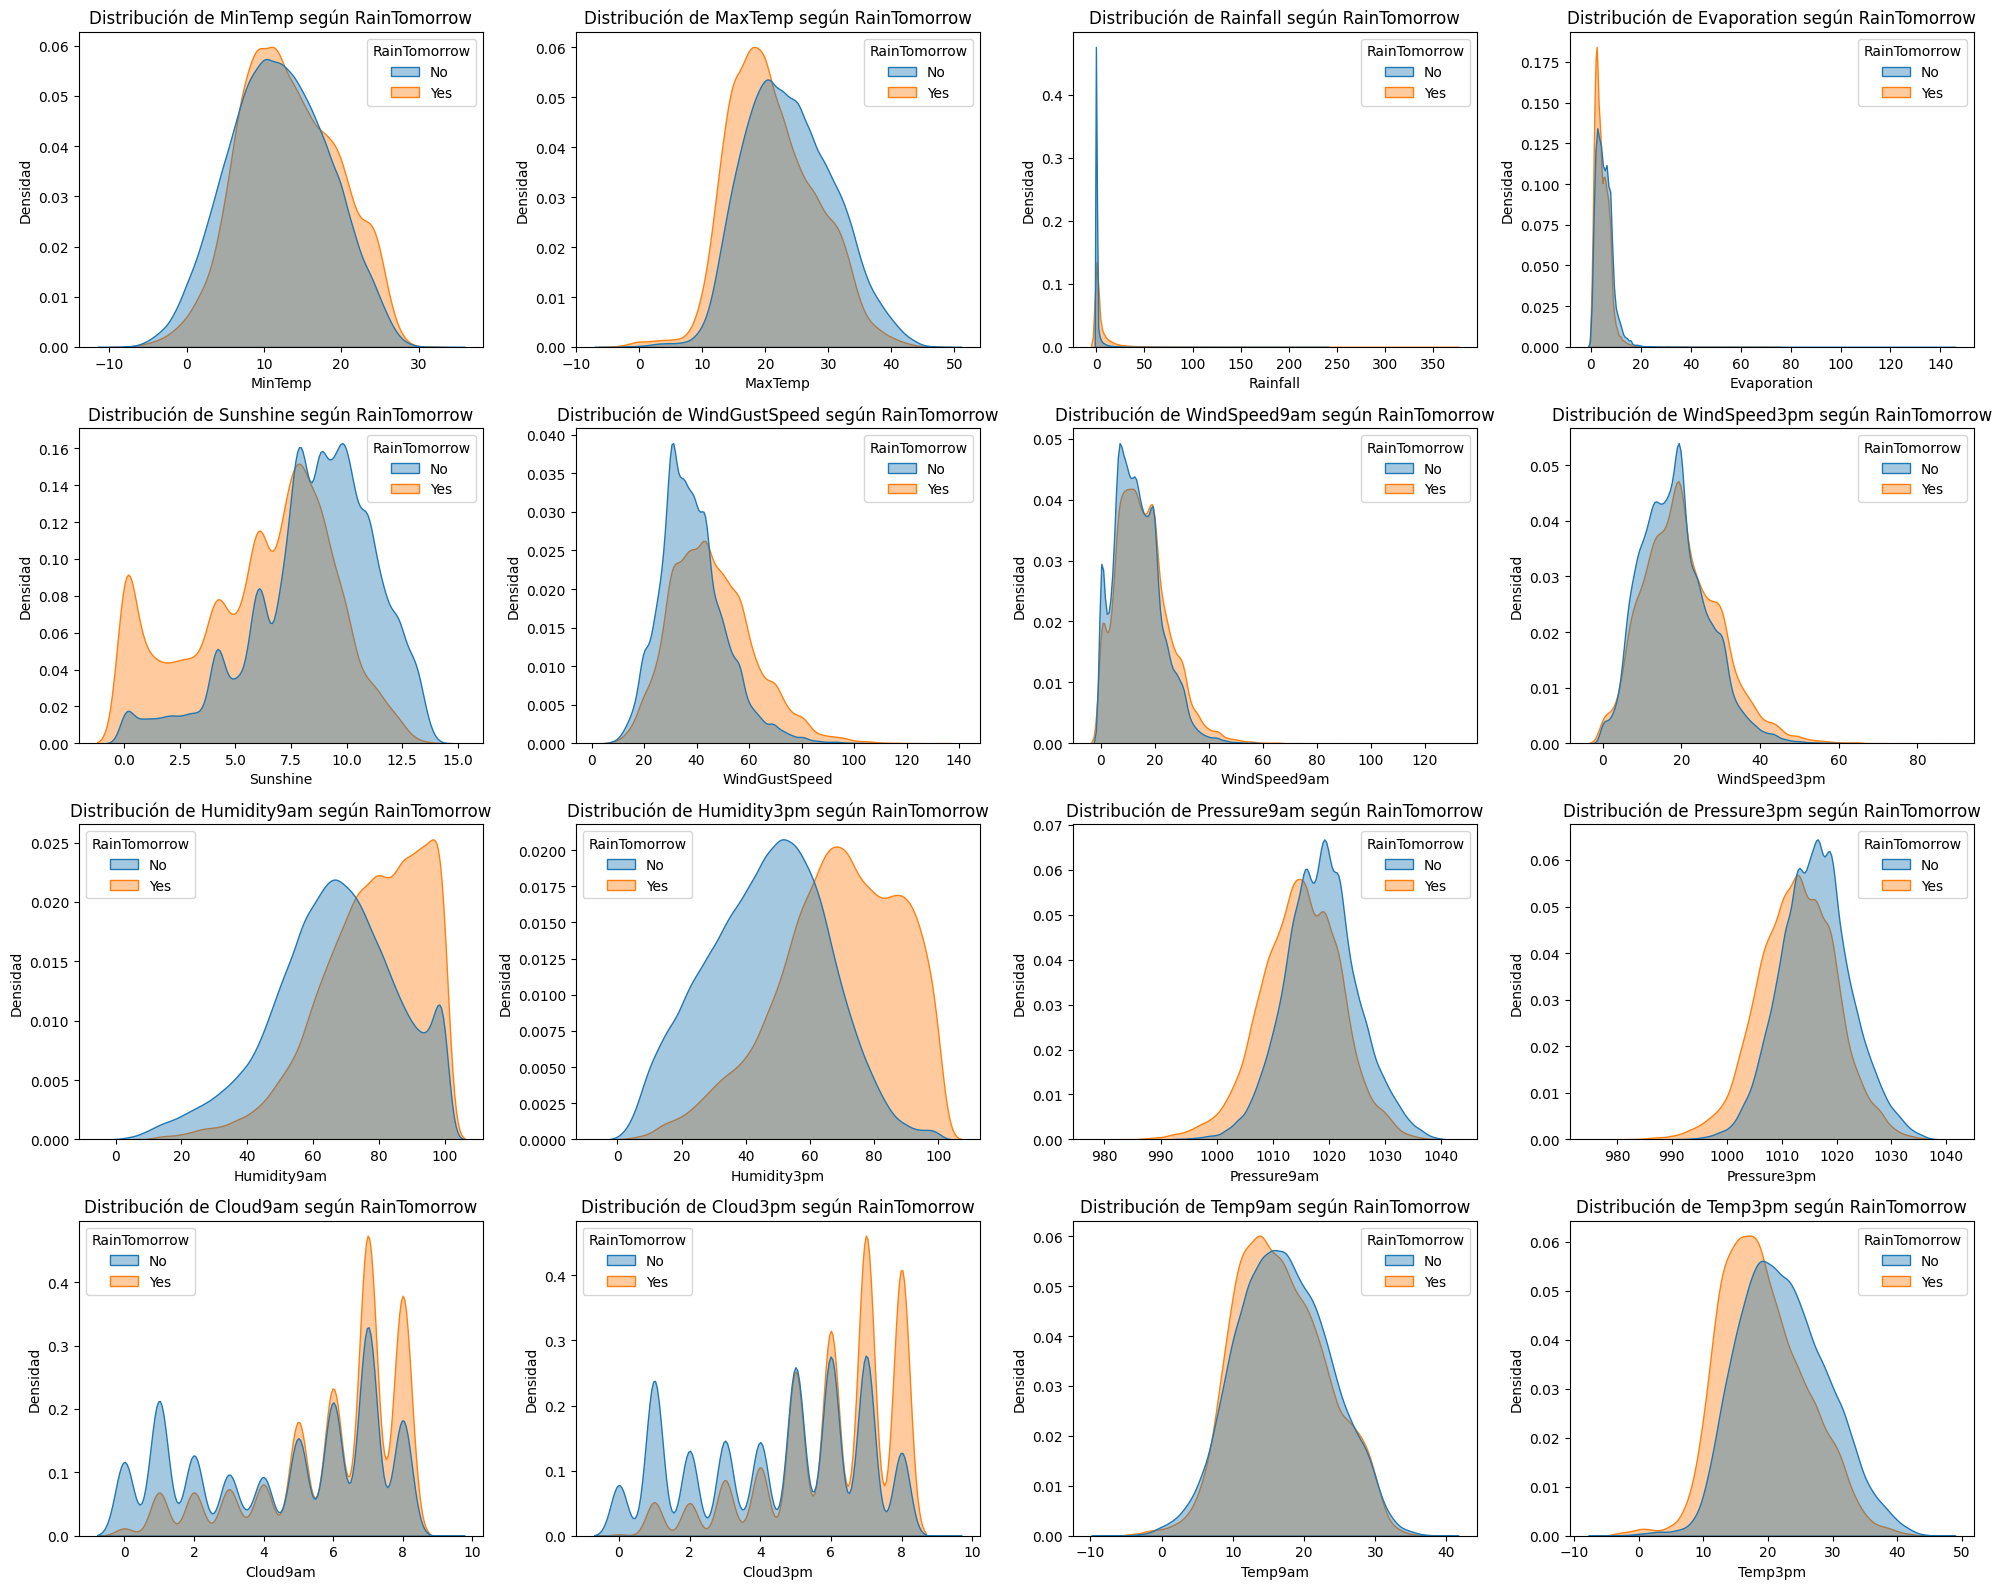

In [172]:
plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.kdeplot(
        data=df,
        x=col,
        hue="RainTomorrow",
        fill=True,
        common_norm=False,
        alpha=0.4
    )
    plt.title(f"Distribución de {col} según RainTomorrow")
    plt.xlabel(col)
    plt.ylabel("Densidad")

plt.tight_layout()
plt.show()

In [173]:
diferencia = distribuciones_post - distribuciones_previo

diferencia

,mean,median,std,var,min,max,IQR,skew,kurtosis,missing_pct
MinTemp,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
MaxTemp,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
Rainfall,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
Evaporation,-0.309033,-0.2,-0.648321,-5.010858,0.0,0.0,-0.4,0.003318,7.321999,-42.779259
Sunshine,0.331555,-0.1,-0.716456,-4.905472,0.0,0.0,-1.8,-0.200861,0.947205,-47.684537
WindGustSpeed,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
WindSpeed9am,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
WindSpeed3pm,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
Humidity9am,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
Humidity3pm,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000


Al mirar las gráficas de distribución de datos de las variables, podemos notar que estas no cambiaron mucho luego de la imputación de datos, así que se considera que no se introdujo ruido en los datos, excepto por Evaporation, dónde varió mucho la Kurtosis (explicación de la métrica). 
En primer lugar, al mirar los boxplots se logra apreciar que no es muy explicativa de la variable Target, sumado a eso que sólo se tenían un 67% de los datos y que al imputarlos, el método elegido añadió bastante ruido se toma la decisión de eliminar la variable por miedo a introducir ruido innecesario al modelo.

In [ ]:
df = df.drop(columns=["Evaporation"]) # bye bye Evap

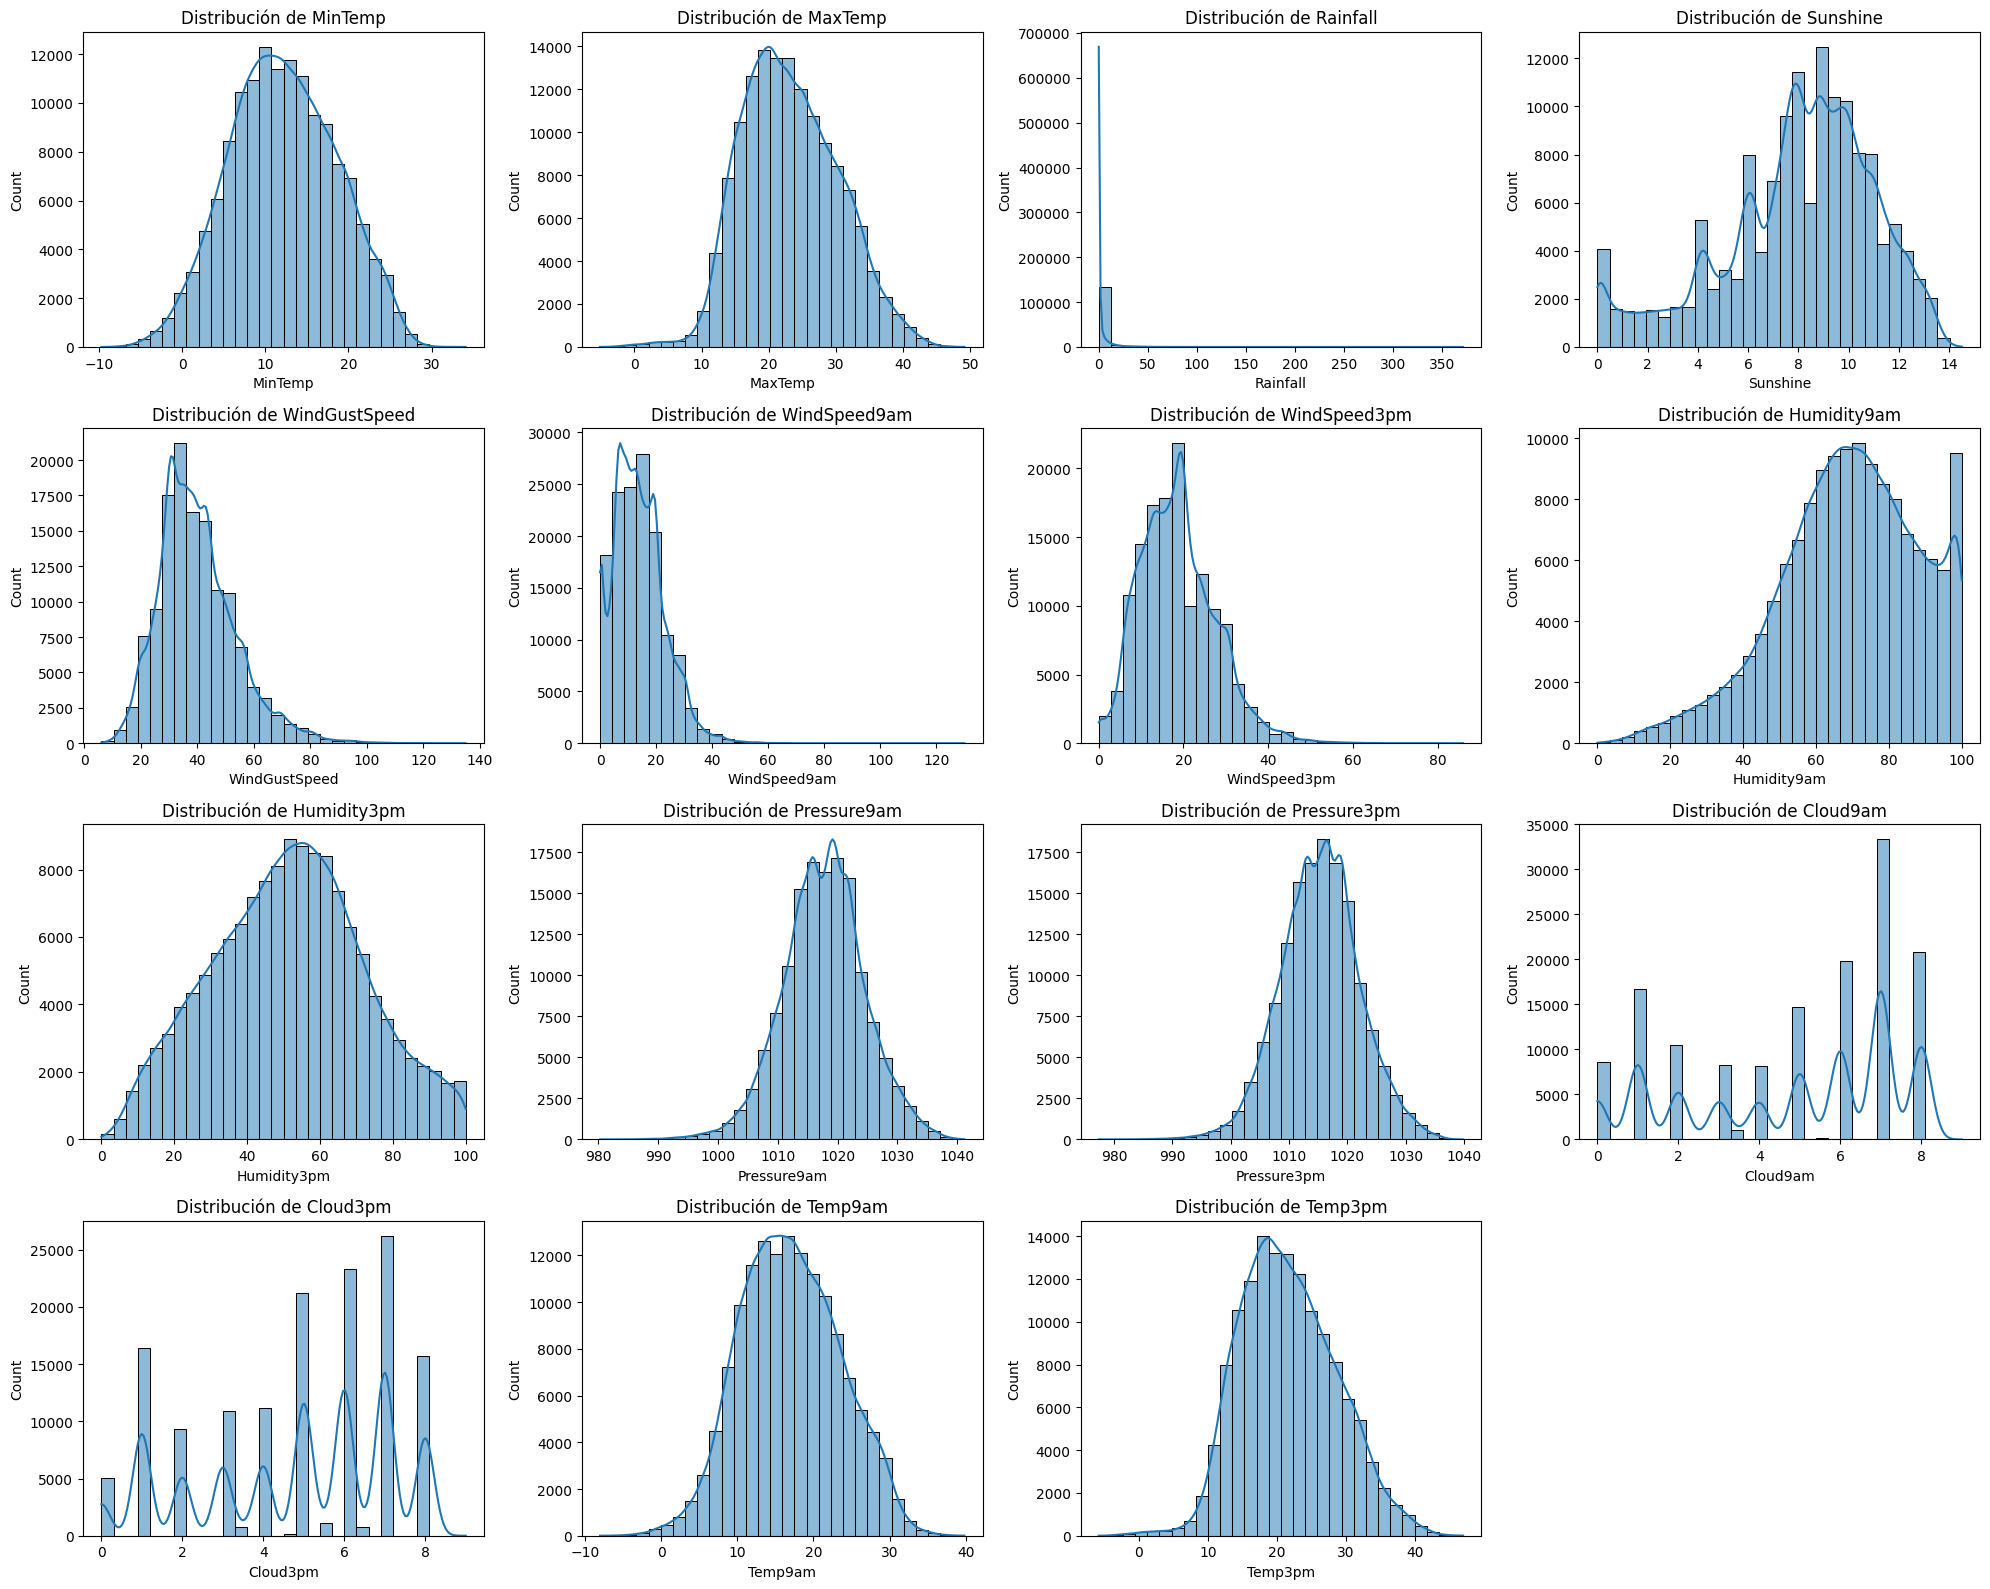

In [175]:
cols_plot = [
    'MinTemp',
    'MaxTemp',
    'Rainfall',
    'Sunshine',
    'WindGustSpeed',
    'WindSpeed9am',
    'WindSpeed3pm',
    'Humidity9am',
    'Humidity3pm',
    'Pressure9am',
    'Pressure3pm',
    'Cloud9am',
    'Cloud3pm',
    'Temp9am',
    'Temp3pm'
]

n_cols = 4
n_rows = math.ceil(len(cols_plot) / n_cols)

plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(cols_plot, 1):

    plt.subplot(n_rows, n_cols, i)

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

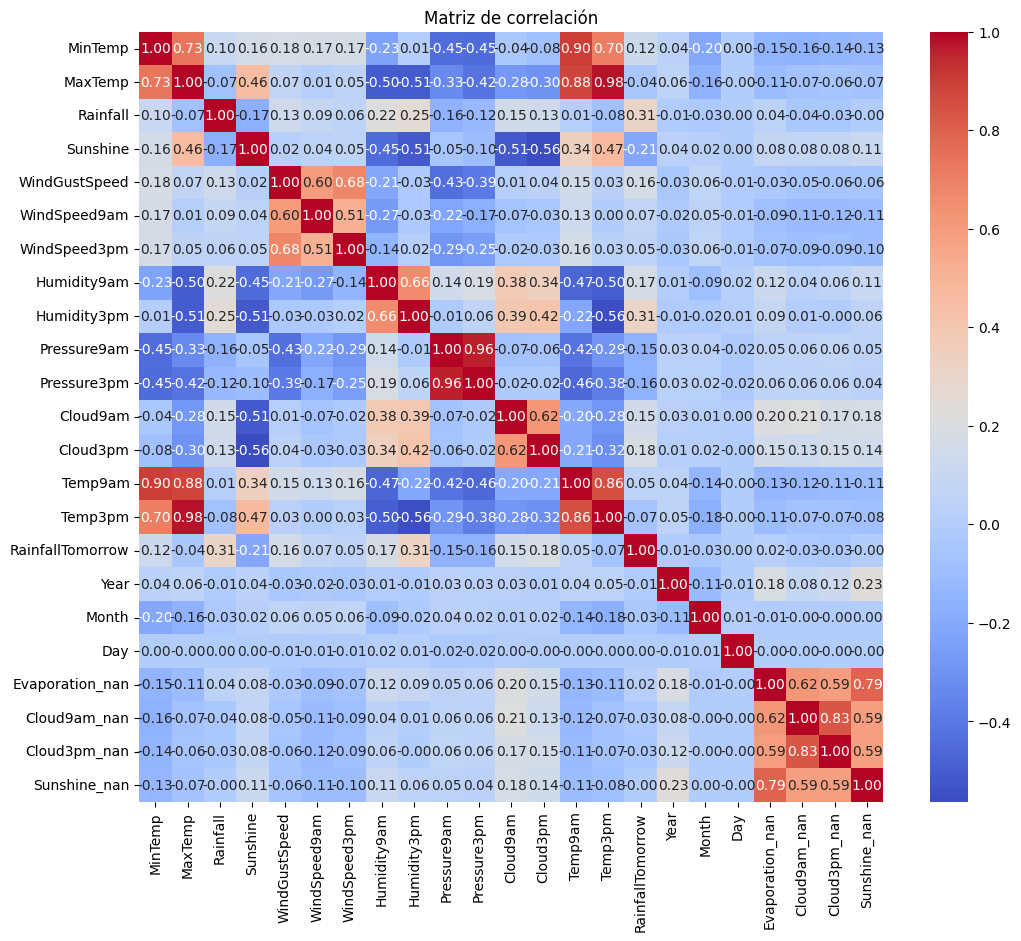

In [177]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()

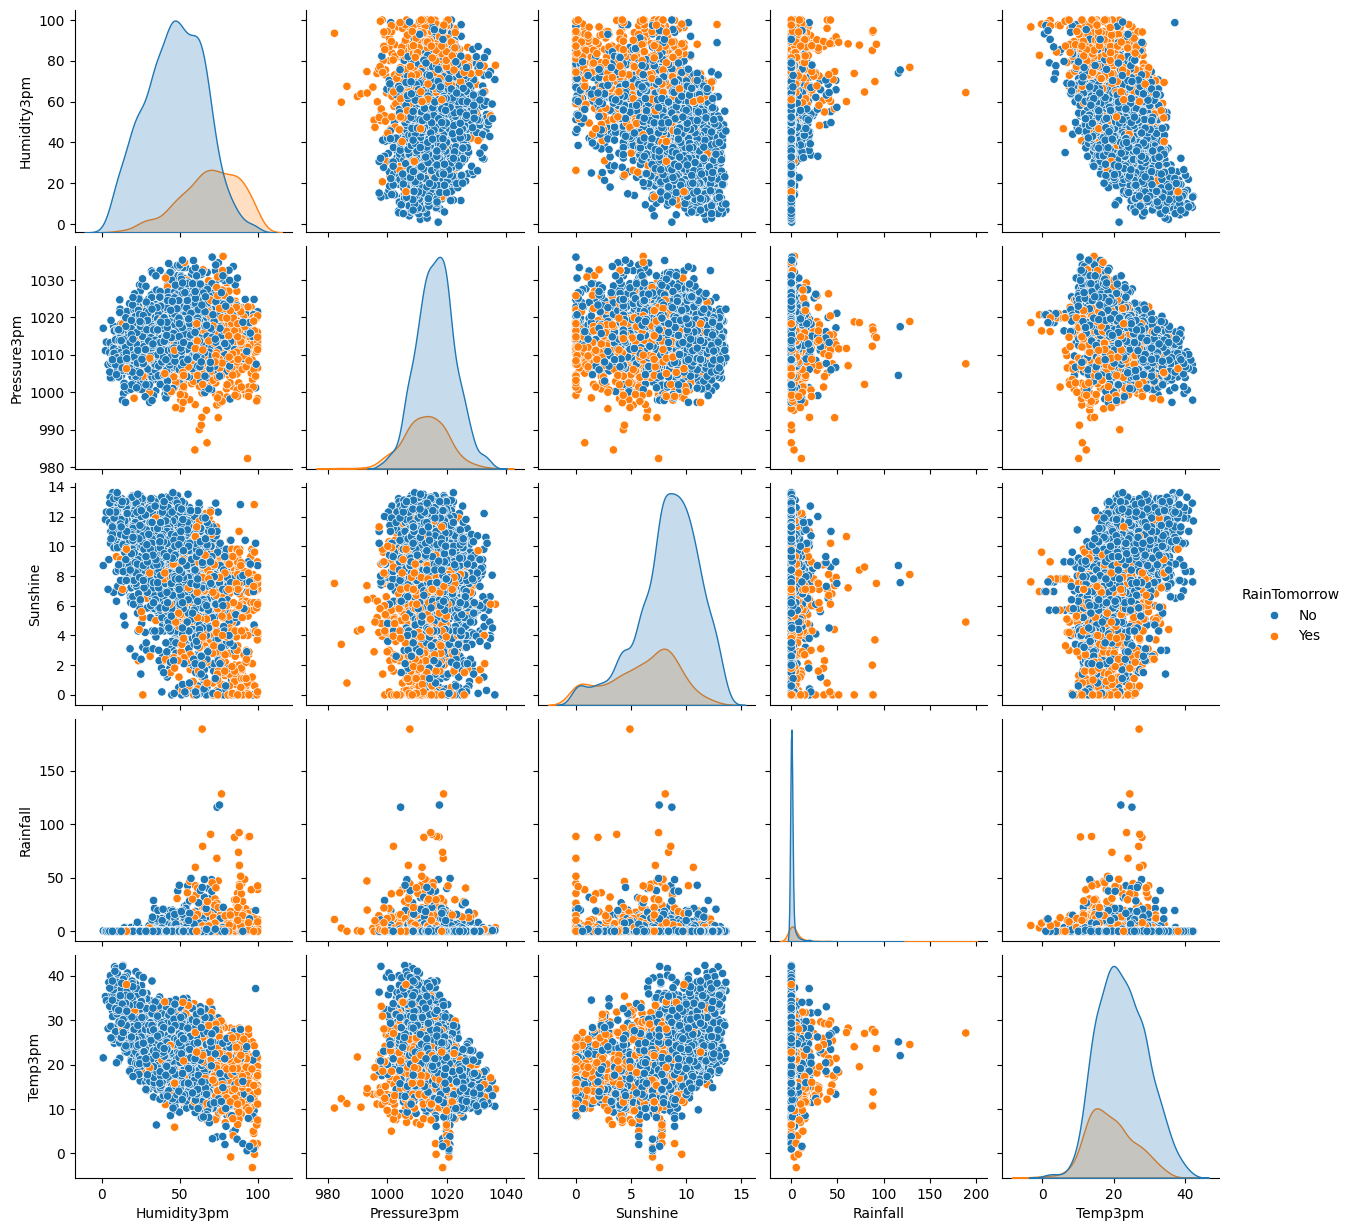

In [178]:
pair_cols = [
    "Humidity3pm",
    "Pressure3pm",
    "Sunshine",
    "Rainfall",
    "Temp3pm",
    "RainTomorrow"
]

sns.pairplot(
    df[pair_cols].sample(3000),
    hue="RainTomorrow"
)

El análisis del pairplot permitió identificar relaciones relevantes entre las variables meteorológicas y la variable objetivo (`RainTomorrow`). Variables como `Humidity3pm`, `Pressure3pm` y `Sunshine` muestran una separación visual clara entre clases, indicando un alto potencial predictivo. En particular, los casos asociados a lluvia futura presentan mayores niveles de humedad, menores niveles de presión atmosférica y menor cantidad de horas de sol. Además, se observaron relaciones coherentes entre variables, como la relación inversa entre humedad y sunshine, y distribuciones altamente asimétricas en variables como `Rainfall`, comportamiento esperable en fenómenos climáticos reales.